In [50]:
!curl -LsSf https://astral.sh/uv/install.sh | bash
!uv --version

downloading uv 0.9.5 x86_64-unknown-linux-gnu
no checksums to verify
installing to /usr/local/bin
  uv
  uvx
everything's installed!
uv 0.9.5


In [51]:
%cd /content/
%rm -rf CS-5137-Deep-Learning

/content


In [52]:
!git clone https://github.com/toan-ly/CS-5137-Deep-Learning
%cd CS-5137-Deep-Learning
!uv sync
%cd homework3

Cloning into 'CS-5137-Deep-Learning'...
remote: Enumerating objects: 995, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 995 (delta 61), reused 87 (delta 32), pack-reused 875 (from 1)
Receiving objects: 100% (995/995), 137.67 MiB | 15.93 MiB/s, done.
Resolving deltas: 100% (244/244), done.
/content/CS-5137-Deep-Learning
Using CPython 3.11.14
Creating virtual environment at: .venv
Resolved 81 packages in 1ms
Installed 75 packages in 239ms
 + asttokens==3.0.0
 + comm==0.2.3
 + contourpy==1.3.3
 + cycler==0.12.1
 + debugpy==1.8.17
 + decorator==5.2.1
 + executing==2.2.1
 + filelock==3.19.1
 + fonttools==4.59.2
 + fsspec==2025.9.0
 + ipykernel==6.30.1
 + ipython==9.6.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + jinja2==3.1.6
 + joblib==1.5.2
 + jupyter-client==8.6.3
 + jupyter-core==5.8.1
 + kiwisolver==1.4.9
 + markupsafe==3.0.2
 + matplotlib==3.10.6
 + matplotlib-inline==0.1.7
 + missingno==0.5.2
 + monai==1.

In [53]:
!uv run -m src.train \
    --data_root ./data \
    --num_workers 2 \
    --cache_rate 1 \
    --epochs 200 --batch_size 32 \
    --loss dice --lr 3e-4 --optimizer adamw \
    --base_channels 32 --depth 3 \
    --early_stopping_patience 20 \
    --save_dir checkpoints --save_plots_path results/predictions \
    --device cuda

Loading dataset: 100% 64/64 [00:00<00:00, 104.90it/s]
Loading dataset: 100% 16/16 [00:00<00:00, 104.36it/s]
Epoch 10/200 - Train Loss: 0.5092, Train Dice: 0.4979, Train IoU: 0.3388 | Val Loss: 0.6621, Val Dice: 0.1506, Val IoU: 0.0836
Figure(800x900)
Epoch 20/200 - Train Loss: 0.4753, Train Dice: 0.5698, Train IoU: 0.4044 | Val Loss: 0.5592, Val Dice: 0.4696, Val IoU: 0.3132
Figure(800x900)
Epoch 30/200 - Train Loss: 0.4729, Train Dice: 0.5752, Train IoU: 0.4099 | Val Loss: 0.4574, Val Dice: 0.6416, Val IoU: 0.4735
Figure(800x900)
Epoch 40/200 - Train Loss: 0.4715, Train Dice: 0.5828, Train IoU: 0.4173 | Val Loss: 0.4453, Val Dice: 0.6377, Val IoU: 0.4697
Figure(800x900)
Epoch 50/200 - Train Loss: 0.4680, Train Dice: 0.5878, Train IoU: 0.4213 | Val Loss: 0.4456, Val Dice: 0.6308, Val IoU: 0.4625
Figure(800x900)
=> Early stopping at epoch 52
Training time: 149.41s | (best val dice = 0.6423)
Model saved to checkpoints/best_model.pth


In [54]:
# %mv results/predictions results/predictions1
# %mv checkpoints checkpoints1
# %mkdir results/predictions
# %mkdir checkpoints

In [55]:
# !uv run -m src.train \
#     --data_root ./data \
#     --num_workers 0 \
#     --cache_rate 1 \
#     --epochs 200 --batch_size 4 --loss bce_dice --lr 1e-4 --base_channels 64 --depth 3 \
#     --early_stopping_patience 20 \
#     --save_dir checkpoints --save_plots_path results/predictions \
#     --device cuda

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

In [57]:
history_df = pd.read_csv('checkpoints/training_history.csv')
history_df.head()

,Unnamed: 0,train_loss,train_dice,train_iou,val_loss,val_dice,val_iou,epoch
0,0,0.676039,0.247115,0.142200,0.660422,0.000000,0.000000,1
1,1,0.647799,0.296833,0.174833,0.662465,0.000000,0.000000,2
2,2,0.632194,0.300507,0.177389,0.664530,0.010687,0.005684,3
3,3,0.619573,0.307592,0.182465,0.666379,0.222157,0.125228,4
4,4,0.604006,0.333142,0.201666,0.668204,0.221750,0.124965,5


In [58]:
def plot_loss(loss_df, save_dir):
    """
    Plots training and validation loss, accuracy, and F1 score
    over epochs for different models and learning rates.
    """

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].plot(loss_df['epoch'], loss_df['train_loss'], label='train_loss')
    axs[0].plot(loss_df['epoch'], loss_df['val_loss'], label='val_loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Training and Validation Loss')
    axs[0].legend()

    axs[1].plot(loss_df['epoch'], loss_df['train_dice'], label='train_dice')
    axs[1].plot(loss_df['epoch'], loss_df['val_dice'], label='val_dice')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Dice')
    axs[1].set_title('Training and Validation Dice')
    axs[1].legend()

    axs[2].plot(loss_df['epoch'], loss_df['train_iou'], label='train_iou')
    axs[2].plot(loss_df['epoch'], loss_df['val_iou'], label='val_iou')
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('IoU')
    axs[2].set_title('Training and Validation IoU')
    axs[2].legend()

    plt.tight_layout()
    plt.show()


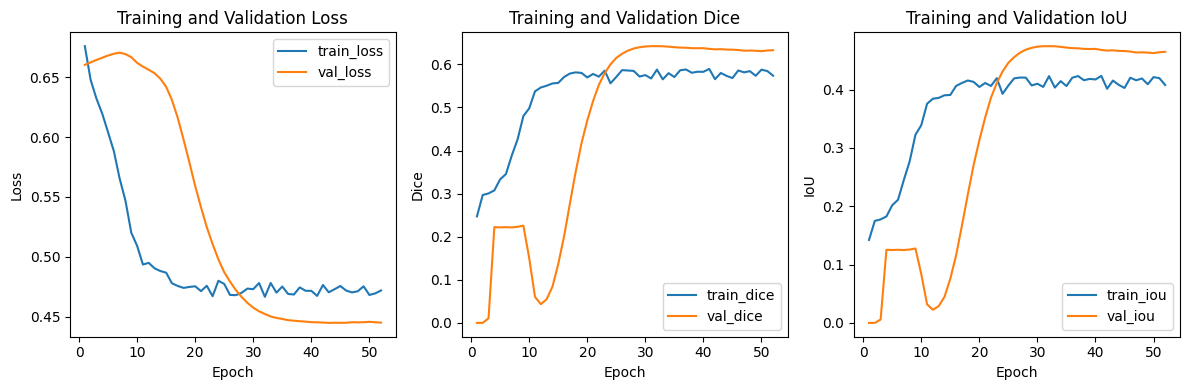

In [59]:
plot_loss(history_df, 'checkpoints')